In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from IPython.display import display, Markdown

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, PolynomialFeatures
)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
)
from sklearn.tree import (
    DecisionTreeRegressor, DecisionTreeClassifier
)
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import (
    KNeighborsRegressor, KNeighborsClassifier
)
from sklearn.svm import SVR, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "Meteorite_Landings.csv"
FIG_DIR = PROJECT_ROOT / "figures"
ART_DIR = PROJECT_ROOT / "artifacts"
MODEL_DIR = PROJECT_ROOT / "models"

for p in [FIG_DIR, ART_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
# 1. Load data
df_raw = pd.read_csv("Meteorite_Landings.csv")
print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)
display(df_raw.head())

Dataset loaded successfully.
Shape: (45716, 10)


,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0000,Fell,"1,880.0000",50.7750,6.0833,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0000,Fell,"1,951.0000",56.1833,10.2333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,"107,000.0000",Fell,"1,952.0000",54.2167,-113.0000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,"1,914.0000",Fell,"1,976.0000",16.8833,-99.9000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0000,Fell,"1,902.0000",-33.1667,-64.9500,"(-33.16667, -64.95)"


In [4]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(dropna=True)
})
display(audit)

print("\nTarget distribution candidates:")
display(df_raw["fall"].value_counts(dropna=False).rename_axis("fall").to_frame("count"))
display(df_raw["nametype"].value_counts(dropna=False).rename_axis("nametype").to_frame("count"))
duplicate_count = df_raw.duplicated().sum()
if duplicate_count > 0:
    df = df_raw.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found. Dataset retained as it is.")

,dtype,missing_count,missing_percent,n_unique
name,str,0,0.0000,45716
id,int64,0,0.0000,45716
nametype,str,0,0.0000,2
recclass,str,0,0.0000,466
mass (g),float64,131,0.2900,12576
fall,str,0,0.0000,2
year,float64,291,0.6400,265
reclat,float64,7315,16.0000,12738
reclong,float64,7315,16.0000,14640
GeoLocation,str,7315,16.0000,17100



Target distribution candidates:


,count
fall,
Found,44609
Fell,1107


,count
nametype,
Valid,45641
Relict,75


No duplicate rows found. Dataset retained as it is.


In [5]:
# Basic statistical summary
display(df_raw.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,45716,45716,Aachen,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,"45,716.0000",NaN,NaN,NaN,"26,889.7351","16,860.6830",1.0000,"12,688.7500","24,261.5000","40,656.7500","57,458.0000"
nametype,45716,2,Valid,45641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recclass,45716,466,L6,8285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mass (g),"45,585.0000",NaN,NaN,NaN,"13,278.0785","574,988.8764",0.0000,7.2000,32.6000,202.6000,"60,000,000.0000"
fall,45716,2,Found,44609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,"45,425.0000",NaN,NaN,NaN,"1,991.8288",25.0528,860.0000,"1,987.0000","1,998.0000","2,003.0000","2,101.0000"
reclat,"38,401.0000",NaN,NaN,NaN,-39.1226,46.3785,-87.3667,-76.7142,-71.5000,0.0000,81.1667
reclong,"38,401.0000",NaN,NaN,NaN,61.0743,80.6473,-165.4333,0.0000,35.6667,157.1667,354.4733
GeoLocation,38401,17100,"(0.0, 0.0)",6214,NaN,NaN,NaN,NaN,NaN,NaN,NaN


TypeError: 'value' must be an instance of str or bytes, not a float

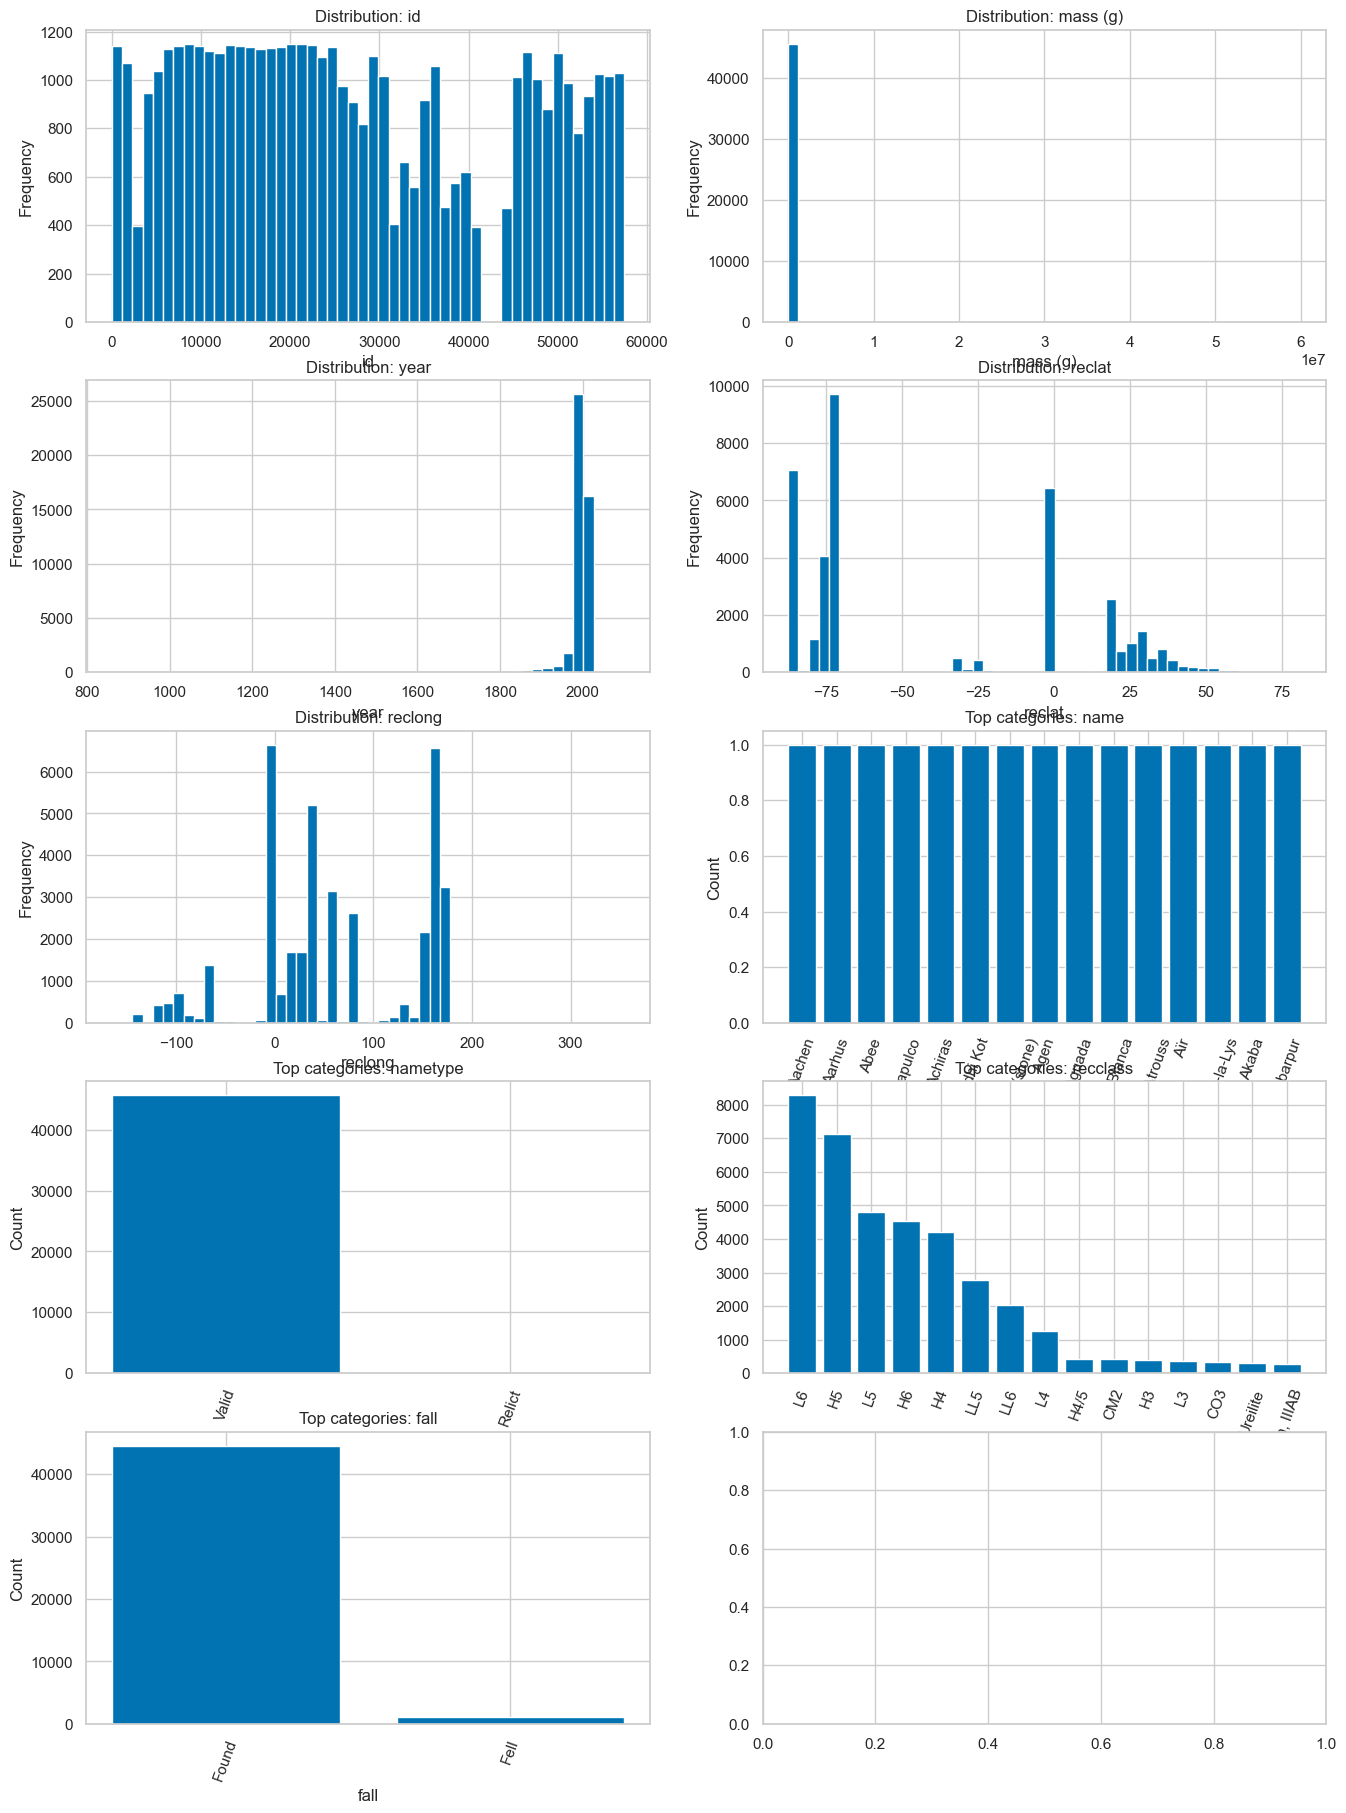

In [15]:
# Distribution plots for every original feature.
# Numeric columns: histograms.
# Categorical/high-cardinality columns: top-category counts or identifier diagnostics.

numeric_original = ["id", "mass (g)", "year", "reclat", "reclong"]
categorical_original = ["name", "nametype", "recclass", "fall", "GeoLocation"]

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.ravel()

# Numeric distributions
for i, col in enumerate(numeric_original):
    ax = axes[i]
    vals = df_raw[col].dropna()
    ax.hist(vals, bins=50)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Categorical/cardinality diagnostics
for j, col in enumerate(categorical_original, start=5):
    ax = axes[j]
    vc = df_raw[col].value_counts(dropna=False).head(15)
    ax.bar(vc.index.astype(str), vc.values)
    ax.set_title(f"Top categories: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=70)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_feature_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

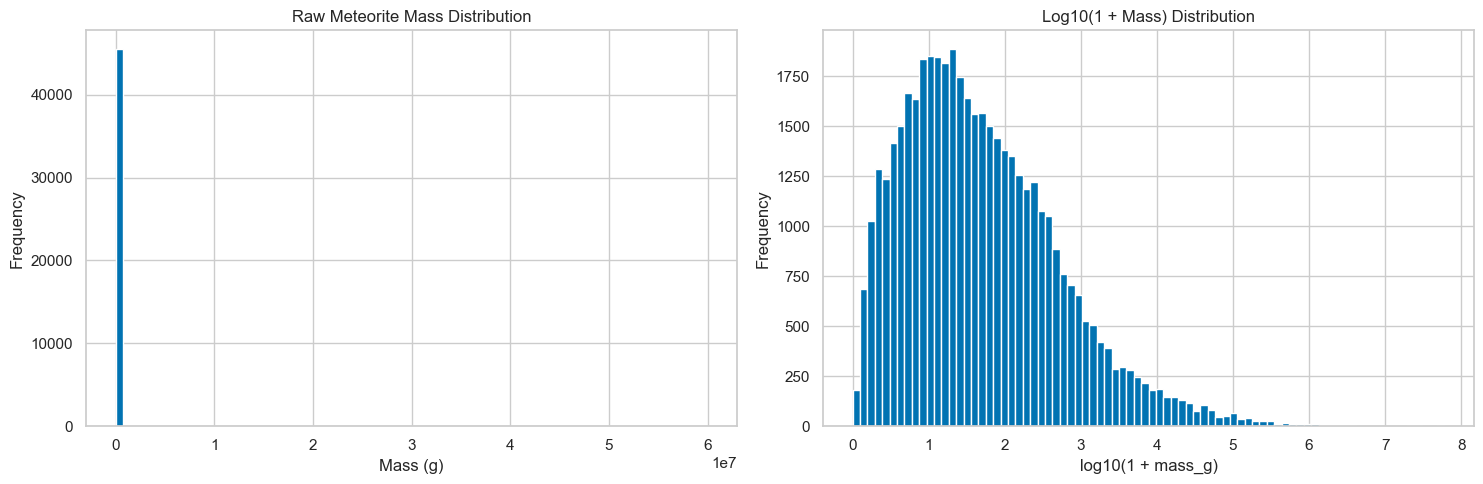

In [16]:
# Target distribution — raw mass and log-transformed mass
mass_valid = df_raw["mass (g)"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(mass_valid, bins=80)
axes[0].set_title("Raw Meteorite Mass Distribution")
axes[0].set_xlabel("Mass (g)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log10(mass_valid + 1), bins=80)
axes[1].set_title("Log10(1 + Mass) Distribution")
axes[1].set_xlabel("log10(1 + mass_g)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

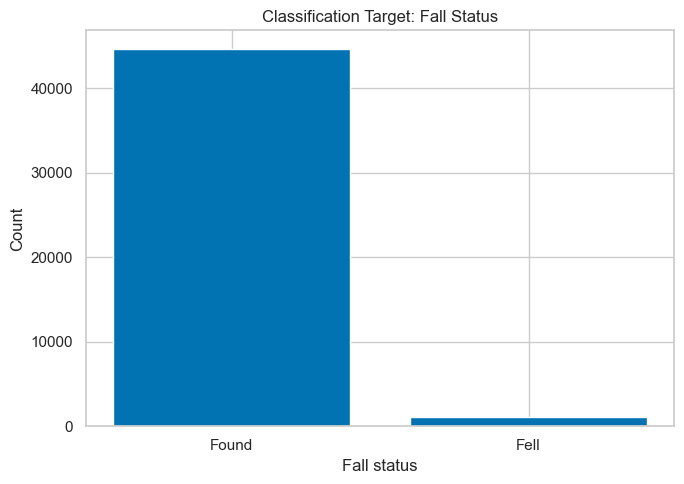

Fall class percentages:


,percent
fall,
Found,97.5800
Fell,2.4200


In [17]:
# Target distribution for classification
fig, ax = plt.subplots(figsize=(7, 5))
fall_counts = df_raw["fall"].value_counts()
ax.bar(fall_counts.index, fall_counts.values)
ax.set_title("Classification Target: Fall Status")
ax.set_xlabel("Fall status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_classification_target.png", dpi=180, bbox_inches="tight")
plt.show()

print("Fall class percentages:")
display((fall_counts / fall_counts.sum() * 100).round(2).rename("percent").to_frame())

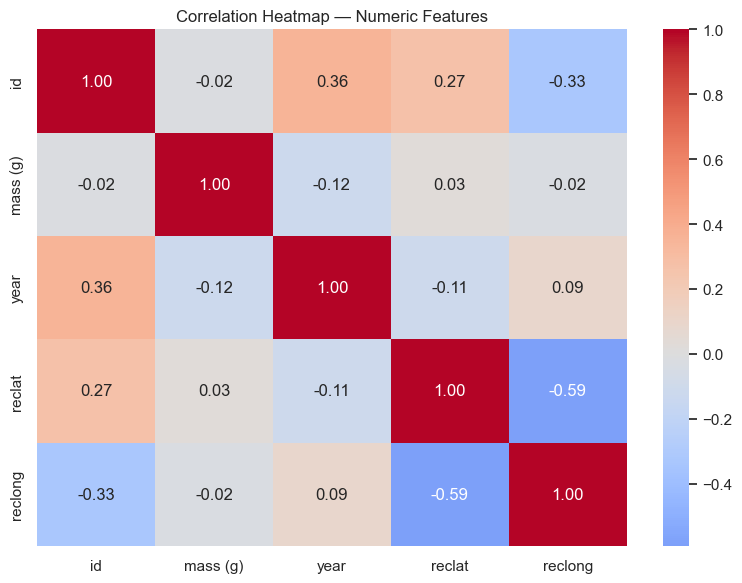

In [18]:
# Correlation heatmap of numeric variables
corr_cols = ["id", "mass (g)", "year", "reclat", "reclong"]
corr = df_raw[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax, cmap="coolwarm", center=0)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

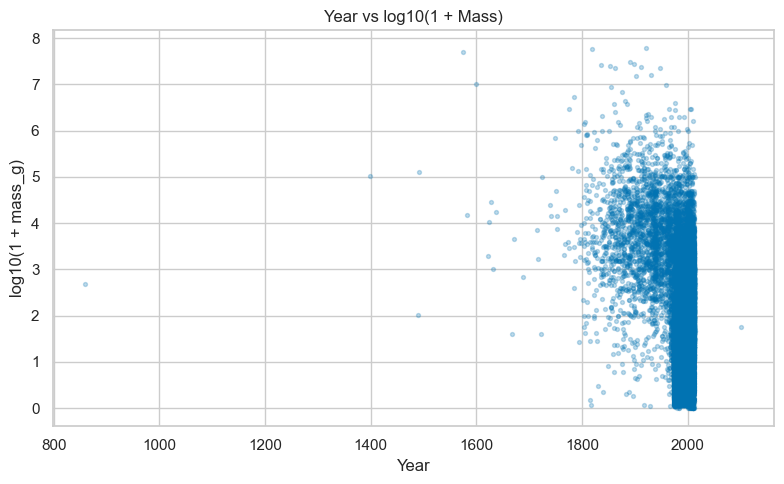

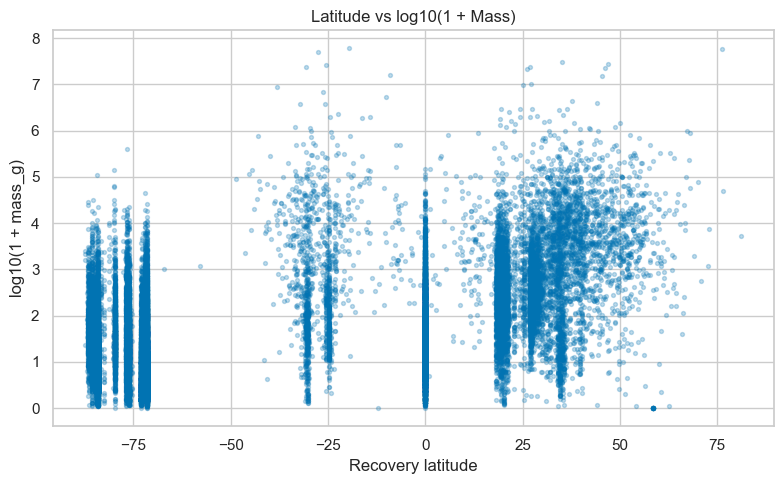

In [19]:
# At least two feature-target scatter plots
eda_tmp = df_raw.dropna(subset=["mass (g)", "year", "reclat"]).copy()
eda_tmp["log_mass"] = np.log10(eda_tmp["mass (g)"] + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(eda_tmp["year"], eda_tmp["log_mass"], s=8, alpha=0.25)
ax.set_title("Year vs log10(1 + Mass)")
ax.set_xlabel("Year")
ax.set_ylabel("log10(1 + mass_g)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_scatter_year_mass.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(eda_tmp["reclat"], eda_tmp["log_mass"], s=8, alpha=0.25)
ax.set_title("Latitude vs log10(1 + Mass)")
ax.set_xlabel("Recovery latitude")
ax.set_ylabel("log10(1 + mass_g)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_scatter_latitude_mass.png", dpi=180, bbox_inches="tight")
plt.show()